In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qnli"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question', 'sentence', 'label', 'idx'],
    num_rows: 104743
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question': 'When did the third Digimon series begin?',
 'sentence': 'Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question'], raw_train_dataset[5]['sentence']

("When is the term 'German dialects' used in regard to the German language?",
 'When talking about the German language, the term German dialects is only used for the traditional regional varieties.')

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question': Value('string'),
 'sentence': Value('string'),
 'label': ClassLabel(names=['entailment', 'not_entailment']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question"], example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question", "sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 84]),
 'token_type_ids': torch.Size([32, 84]),
 'attention_mask': torch.Size([32, 84])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7970, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

In [26]:
from train_eval_func import eval_loop

In [27]:
eval_loop(model, val_dataloader, task_name, device)

({'accuracy': 0.5244371224601867}, 0.8301020944327638)

# 5. Learning Rate and Leanring Scheduler Setup

In [28]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=3e-5)

In [29]:
from train_eval_func import set_lr_scheduler

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = set_lr_scheduler(
    optimizer          = optimizer,
    num_training_steps = num_training_steps
)

print(num_training_steps)

9822


In [30]:
patience=3
save_path=f'./weights/bert-{task_name}.pt'

# 6. Training

In [31]:
from train_eval_func import train

In [32]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=num_epochs,
    lr=lr_scheduler,
    patience=patience,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    save_path=save_path,
    display_epoch_iter=True
)

Training:   0%|          | 0/9822 [00:00<?, ?it/s]/home/abhinavl/work/Layer_Graft/layer-grafting-publication/glue_fine_tune/../train_eval_func.py:196: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  33%|███▎      | 3274/9822 [07:32<27:18,  4.00it/s]

✓ Saved checkpoint (best loss: 0.2437)

<----------------- Epoch 1 ----------------->
Loss: 0.33, Training Metrics:
  accuracy: 0.8615
Validation Loss: 0.24, Validation Metrics:
  accuracy: 0.9077
Elapsed Time: 461.2273 sec


Training:  67%|██████▋   | 6547/9822 [15:22<08:08,  6.71it/s]   

✓ Saved checkpoint (best loss: 0.2596)

<----------------- Epoch 2 ----------------->
Loss: 0.17, Training Metrics:
  accuracy: 0.9380
Validation Loss: 0.26, Validation Metrics:
  accuracy: 0.9109
Elapsed Time: 458.257 sec


Training: 100%|██████████| 9822/9822 [23:32<00:00,  6.96it/s]  

✓ Saved checkpoint (best loss: 0.5166)

<----------------- Epoch 3 ----------------->
Loss: 0.12, Training Metrics:
  accuracy: 0.9729
Validation Loss: 0.52, Validation Metrics:
  accuracy: 0.9134
Elapsed Time: 457.0313 sec

Total Training Time: 1412.22 sec
Chosen Primary Metric: accuracy
Best Metric Run: 0.9134


### Plotting Loss

In [33]:
from train_eval_func import plotLoss, plotAccuracy

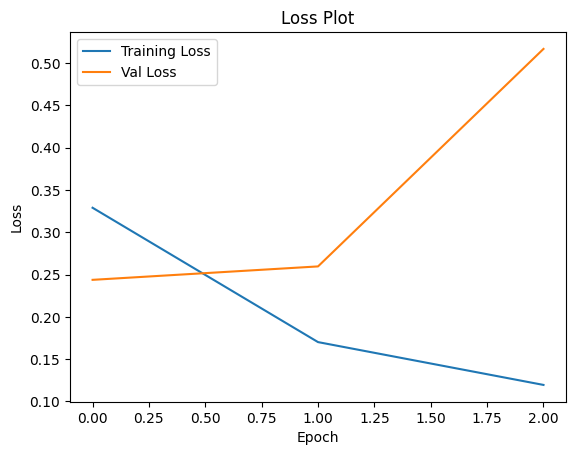

In [34]:
plotLoss(train_stats['train_losses'], train_stats['val_losses'], title="Loss Plot")

### Plotting Accuracy

In [35]:
def getMetricList(train_stats, metric_name='accuracy'):
    train_values = [m[metric_name] for m in train_stats['train_metrics_history']]
    val_values = [m[metric_name] for m in train_stats['val_metrics_history']]

    return train_values, val_values

In [36]:
train_values, val_values = getMetricList(train_stats)

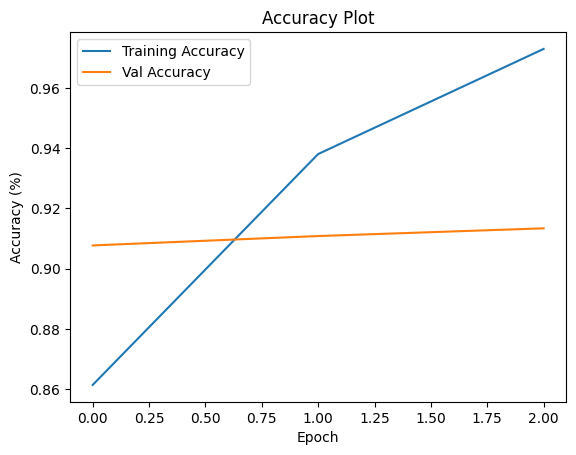

In [37]:
plotAccuracy(train_values, val_values, title="Accuracy Plot")

# 7. Evaluation

In [38]:
best_weight = torch.load(save_path)

In [39]:
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [40]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9134175361522973}